In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import FOMO functions

In [2]:
import sys
sys.path.append("../../")
from fomo.patterns.missing_data_matrix import missing_data_matrix, flag_missing_data
from fomo.patterns.missing_data_probabilities import missing_data_probabilities
from fomo.patterns.missing_pattern_plot import MissingPatternPlot

# Test 1: Known 50% Always

## Make dataset

Artificial dataset: every other value of Missing_Flag is True/False, intervals are 15 minutes

In [3]:
# Creating the datetime range
start_date = "2024-01-01"
end_date = "2024-01-29"
datetime_range = pd.date_range(start=start_date, end=end_date, freq='15T', inclusive='left')

# Creating the dataframe
df = pd.DataFrame({
    "person_id": np.ones(len(datetime_range), dtype=int),  # All values are 1
    "datetime": datetime_range,
    "heart_rate": np.random.uniform(low=60, high=100, size=len(datetime_range)),
    "Missing_Flag": np.tile([False, True], len(datetime_range)//2)
})

# Setting heart_rate to NaN where Missing_Flag is True
df.loc[df['Missing_Flag'], 'heart_rate'] = np.nan

flagged_df_50percent = df
flagged_df_50percent.head()


/var/folders/5y/klq_vsbn365gv4d3wvljm_lr0000gn/T/ipykernel_10947/2788731677.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  datetime_range = pd.date_range(start=start_date, end=end_date, freq='15T', inclusive='left')


,person_id,datetime,heart_rate,Missing_Flag
0,1,2024-01-01 00:00:00,69.316507,False
1,1,2024-01-01 00:15:00,NaN,True
2,1,2024-01-01 00:30:00,94.841794,False
3,1,2024-01-01 00:45:00,NaN,True
4,1,2024-01-01 01:00:00,90.446824,False


## Test missing_data_probabilities

Test 1: 30 minute intervals \
Expected output: All values should be 0.5, as long as missingness_interval is an integer multiple of 30

In [4]:
missingness_avg, missingness_var = missing_data_probabilities(flagged_df_50percent, time_column='datetime', axes="day", missingness_interval=30)
missingness_avg

/Users/shunsakai/Desktop/Bass S2024/FOMO/fomo/examples/../../fomo/patterns/missing_data_probabilities.py:51: FutureWarning: The 'axis' keyword in DataFrame.rolling is deprecated and will be removed in a future version. Call the method without the axis keyword instead.
  resampled_matrix = matrix.rolling(window=indexer, axis=0, min_periods=1).mean()


array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

# Test 2: 6am-6pm only

## Make artificial dataset
In this artificial dataset, starting exactly at 6:00am, all values are not missing. Then starting at 18:00, all values are missing. 

In [5]:
# Recreating the datetime range
datetime_range = pd.date_range(start=start_date, end=end_date, freq='15T', inclusive='left')

# Function to set Missing_Flag based on the time condition
def set_missing_flag(hour):
    if hour >= 18  or hour < 6:  # From 6pm to 6am, make data missing (return True)
        return True
    else:
        return False

# Creating the new dataframe from scratch with the adjusted Missing_Flag condition
df_new = pd.DataFrame({
    "person_id": np.ones(len(datetime_range), dtype=int),
    "datetime": datetime_range
})

df_new['Missing_Flag'] = df_new['datetime'].dt.hour.apply(set_missing_flag)
df_new['heart_rate'] = np.random.uniform(low=60, high=100, size=len(datetime_range))
df_new.loc[df_new['Missing_Flag'], 'heart_rate'] = np.nan

flagged_df_midday = df_new
flagged_df_midday.head()


/var/folders/5y/klq_vsbn365gv4d3wvljm_lr0000gn/T/ipykernel_10947/985378613.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  datetime_range = pd.date_range(start=start_date, end=end_date, freq='15T', inclusive='left')


,person_id,datetime,Missing_Flag,heart_rate
0,1,2024-01-01 00:00:00,True,NaN
1,1,2024-01-01 00:15:00,True,NaN
2,1,2024-01-01 00:30:00,True,NaN
3,1,2024-01-01 00:45:00,True,NaN
4,1,2024-01-01 01:00:00,True,NaN


## Test missing_data_probabilities

Test 1: hours \
Expected output: 6 1's, followed by 12 0's, followed by 6 1's

In [6]:
missingness_avg, missingness_var = missing_data_probabilities(flagged_df_midday, time_column='datetime', axes="day", missingness_interval=60)
missingness_avg

/Users/shunsakai/Desktop/Bass S2024/FOMO/fomo/examples/../../fomo/patterns/missing_data_probabilities.py:51: FutureWarning: The 'axis' keyword in DataFrame.rolling is deprecated and will be removed in a future version. Call the method without the axis keyword instead.
  resampled_matrix = matrix.rolling(window=indexer, axis=0, min_periods=1).mean()


array([1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 1., 1., 1., 1.])

Test 2: 6 hour intervals \
Expected output: [1,0,0,1]

In [7]:
missingness_avg, missingness_var = missing_data_probabilities(flagged_df_midday, time_column='datetime', axes="day", missingness_interval=60*6)
missingness_avg

/Users/shunsakai/Desktop/Bass S2024/FOMO/fomo/examples/../../fomo/patterns/missing_data_probabilities.py:51: FutureWarning: The 'axis' keyword in DataFrame.rolling is deprecated and will be removed in a future version. Call the method without the axis keyword instead.
  resampled_matrix = matrix.rolling(window=indexer, axis=0, min_periods=1).mean()


array([1., 0., 0., 1.])

Test 3: Week Level, 24 hour intervals \
Expected output: all values should be 0.5

In [8]:
missingness_avg, missingness_var = missing_data_probabilities(flagged_df_midday, time_column='datetime', axes="week", missingness_interval=60*24)
missingness_avg

/Users/shunsakai/Desktop/Bass S2024/FOMO/fomo/examples/../../fomo/patterns/missing_data_probabilities.py:51: FutureWarning: The 'axis' keyword in DataFrame.rolling is deprecated and will be removed in a future version. Call the method without the axis keyword instead.
  resampled_matrix = matrix.rolling(window=indexer, axis=0, min_periods=1).mean()


array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

Test 4 day x week, 6 hours \
Expected output: [1, 0, 0, 1] repeated 7 times

In [9]:
missingness_avg, missingness_var = missing_data_probabilities(flagged_df_midday, time_column='datetime', axes=['day', "week"], missingness_interval=60*6)
missingness_avg

/Users/shunsakai/Desktop/Bass S2024/FOMO/fomo/examples/../../fomo/patterns/missing_data_probabilities.py:51: FutureWarning: The 'axis' keyword in DataFrame.rolling is deprecated and will be removed in a future version. Call the method without the axis keyword instead.
  resampled_matrix = matrix.rolling(window=indexer, axis=0, min_periods=1).mean()


array([[1., 0., 0., 1.],
       [1., 0., 0., 1.],
       [1., 0., 0., 1.],
       [1., 0., 0., 1.],
       [1., 0., 0., 1.],
       [1., 0., 0., 1.],
       [1., 0., 0., 1.]])

## Test 3: Saturday/Sunday Dependencies

## Make dataset
This dataset is similar to test 2 (always missing between 6pm and 6am), except 
* Values are ALL missing on Saturdays
* On Sundays, values are only present noon-6pm

In [10]:
datetime_range = pd.date_range(start=start_date, end=end_date, freq='15T', inclusive='left')

# Function to set Missing_Flag based on the new conditions (Saturday, Sunday with specific hours)
def set_advanced_missing_flag(row):
    if row.dayofweek == 5:  # Saturday
        return True
    elif row.dayofweek == 6:  # Sunday
        # True except for noon to 6pm
        if 12 <= row.hour < 18:
            return False
        else:
            return True
    else:
        if row.hour >= 18 or row.hour < 6:  # From 6pm to 6am
            return True
        else:
            return False

# Creating the new dataframe from scratch with the updated Missing_Flag condition
df_advanced = pd.DataFrame({
    "person_id": np.ones(len(datetime_range), dtype=int),
    "datetime": datetime_range
})

df_advanced['Missing_Flag'] = df_advanced['datetime'].apply(set_advanced_missing_flag)
df_advanced['heart_rate'] = np.random.uniform(low=60, high=100, size=len(datetime_range))
df_advanced.loc[df_advanced['Missing_Flag'], 'heart_rate'] = np.nan

flagged_df_weekend = df_advanced
flagged_df_weekend.head()

weekend_df_val = flagged_df_weekend.copy()
weekend_df_val['date'] = weekend_df_val['datetime'].dt.date

print('1/6 is a Saturday, so that should be equal to 1.0, 1/7 should be 0.75')
print((weekend_df_val.groupby('date')['Missing_Flag'].sum() / 96).head(7))


1/6 is a Saturday, so that should be equal to 1.0, 1/7 should be 0.75
date
2024-01-01    0.50
2024-01-02    0.50
2024-01-03    0.50
2024-01-04    0.50
2024-01-05    0.50
2024-01-06    1.00
2024-01-07    0.75
Name: Missing_Flag, dtype: float64


/var/folders/5y/klq_vsbn365gv4d3wvljm_lr0000gn/T/ipykernel_10947/2827922896.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  datetime_range = pd.date_range(start=start_date, end=end_date, freq='15T', inclusive='left')


## Test missing_data_probabilities

Test 1: Simple week (24 hour intervals) \
Expected output: All values should be 0.5, but the day corresponding to saturday should be 1.0, and the day corresponding to Sunday should be 0.75 \
Without deliberate sorting by weekdays, I think the correct output is [0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 0.75] \
If you're sorting by weekdays, the correct output is [0.75, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0]

In [11]:
missingness_avg, missingness_var = missing_data_probabilities(flagged_df_weekend, time_column='datetime', axes="week", missingness_interval=60*24)
missingness_avg

/Users/shunsakai/Desktop/Bass S2024/FOMO/fomo/examples/../../fomo/patterns/missing_data_probabilities.py:51: FutureWarning: The 'axis' keyword in DataFrame.rolling is deprecated and will be removed in a future version. Call the method without the axis keyword instead.
  resampled_matrix = matrix.rolling(window=indexer, axis=0, min_periods=1).mean()


array([0.5 , 0.5 , 0.5 , 0.5 , 0.5 , 1.  , 0.75])

Test 2: day x week (6 hour intervals) \
Expected output: All weekdays should be [1, 0, 0, 1], Sunday should be [1, 1, 0, 1], and Saturday should be [1, 1, 1, 1]

In [16]:
import numpy as np
import pandas as pd

def missing_data_probabilities(flagged_df, time_column, axes, basis_rate=15, missingness_interval=15, missing_flags_column='Missing_Flag'):
    """
    Calculate missingness probability and variance matrices (or tensors) along a time axis
    An axis can be "day", "week", "year"
    
    Parameters
    ----------
    flagged_df: pandas.DataFrame
	    Dataframe with flagged missingness for one person. Flags can be obtained with flag_missing_data
    time_column: str
	    Name of column in dataframe which contains the time information. Column should have dtype datetime
    axes: str or list of str's ["day", "week", "year"]
	    Axis of the final output vector/matrix/tensor which denotes a unit/scale of time, along which to check for missingness
    basis_rate: Integer, how big of a gap there is between data points in output table in minutes
    missingness_interval: For fractional missingness, how big of interval to consider in final matrix.
	  missing_flags_column: str default='Missing_Flag'
		  Name of column in dataframe which contains boolean missingness flags. 
		  If dataframe was generated with flag_missing_data, the default value "Missing_Flag" should be correct
		  
    """
    
    # Step 1: Implement similar logic to missing_data_matrix, but for one person
    # Instead of making each time point be one column, each time point should be a row. Therefore, make a "Time" column in the intermediate dataframe, or make time the index of a pandas Series
    
     # Check if flagged_df has Missing Flag column
    if 'Missing_Flag' not in flagged_df.columns:
        raise Exception("No Missing Flags in provided dataframe")

    # Check if missingness_interval > basis_rate
    if missingness_interval < basis_rate:
        raise Exception("Resampling Error: missingness_interval must be greater than basis_rate.")
    
     # Convert Missing_Flag to integer to calculate percentages later
    flagged_df['Missing_Flag'] = flagged_df['Missing_Flag'].astype(int)

    # Create matrix where we take all columns but the datatime column
    matrix = flagged_df

    # perform rolling mean to get the percentage of missing values within each interval
    matrix = matrix.set_index(time_column)

    # Calculate the number of basis_rate intervals within each missingness_interval
    intervals_per_group = missingness_interval // basis_rate

    # Use rolling mean to calculate the percentage of missing values within each interval
    # Note: The window size is set to intervals_per_group, and min_periods is set to 1 to ensure that we get a value even if there's only one non-missing value in the window.
    indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=intervals_per_group) # makes sure that the timestamp for missing_data_matrix represents the beginning of the interval
    resampled_matrix = matrix.rolling(window=indexer, axis=0, min_periods=1).mean()

    # let the index be just numbers and move the datatime to be a new column
    resampled_matrix = resampled_matrix.reset_index()

    # only keep datetime and missingness columns
    resampled_matrix = resampled_matrix[[time_column, missing_flags_column]]

    # Since rolling mean includes the current and previous (window-1) columns, we need to select every intervals_per_group-th row to get non-overlapping intervals
    resampled_matrix = resampled_matrix.iloc[[0] + [i for i in range(intervals_per_group, len(resampled_matrix), intervals_per_group)], :]

    # get and store the unique time values, day values, and number of weeks
    time_values = resampled_matrix[time_column].dt.strftime('%H:%M').unique()
    day_values = resampled_matrix[time_column].dt.day_name().unique()
    num_weeks = np.ceil(len(resampled_matrix) / (len(day_values) * len(time_values))).astype(int)

    # create intermediate pandas df that contains all values needed to calculate any set of input axes
    missingness_matrix_week = resampled_matrix.copy()
    
    # every set of len(day_values) * len(time_values) rows will have the same week value up to the last value in the matrix
    missingness_matrix_week['Week'] = np.repeat(np.arange(num_weeks), len(day_values) * len(time_values))[:len(resampled_matrix)]
    missingness_matrix_week['Full-Time'] = resampled_matrix[time_column].dt.day_name() + missingness_matrix_week['Week'].astype(str) + ':' + resampled_matrix[time_column].dt.strftime('%H:%M')
    missingness_matrix_week['Day-Week'] = resampled_matrix[time_column].dt.day_name() + missingness_matrix_week['Week'].astype(str)
    missingness_matrix_week['Day-Time'] = resampled_matrix[time_column].dt.day_name() + resampled_matrix[time_column].dt.strftime('%H:%M')
    missingness_matrix_week['Time'] = resampled_matrix[time_column].dt.strftime('%H:%M')
    day_week_values = missingness_matrix_week['Day-Week'].unique()

    # keep only the time and missingness columns, rename the missingness column to Missing_Fraction, and reset the index
    missingness_matrix_week = missingness_matrix_week.rename(columns={missing_flags_column: 'Missing_Fraction'})
    missingness_matrix_week = missingness_matrix_week.reset_index(drop=True)

    # Step 2: Unflatten time points. The first axis is in minutes and should be at the sampling rate of missingness_interval
    unflattened_matrix = None

    # make intermediate matrix for each of the unique axes
    if isinstance(axes, str) or len(axes) == 1:
        if axes == 'day' or axes[0] == 'day':
            # axes = day
            unflattened_day_matrix = missingness_matrix_week.pivot(index='Day-Week', columns='Time', values='Missing_Fraction')
            unflattened_day_matrix = unflattened_day_matrix.reindex(day_week_values)
            unflattened_matrix = unflattened_day_matrix.to_numpy() # note: day is a time_of_day x day (happens to correspond to day of week)
        elif axes == 'week' or axes[0] == 'week':
            # axes = week
            original_order = missingness_matrix_week['Day-Time'].unique()
            unflattened_week_matrix = missingness_matrix_week.pivot(index='Week', columns='Day-Time', values='Missing_Fraction').reindex(columns=original_order)
            unflattened_matrix = unflattened_week_matrix.to_numpy() # note: week is a unique_days x week
        else:
            raise Exception("Invalid axes input")
    elif isinstance(axes, list):
        if axes == ['day', 'week'] or axes == ['week', 'day']:
            """in this case, we need to have complete sets of weeks. thus, we will fill in any incomplete weeks with nans before creating the tensor"""
            # original unflattened day matrix with potentially missing days of the week
            unflattened_day_matrix = missingness_matrix_week.pivot_table(index='Day-Week', columns='Time', values='Missing_Fraction')
            unflattened_day_matrix = unflattened_day_matrix.reindex(day_week_values)

            # create a new list for every day_of_week + week combination
            full_day_week = []
            for w in range(num_weeks):
                for d in day_values:
                    full_day_week.append(d + str(w))

            # extend unflattened matrix to have all day_of_week + week combinations
            full_unflattened_matrix = unflattened_day_matrix.reindex(full_day_week, fill_value=np.nan)
            
            # transform pands df into 2d numpy array where each row is a day of the week and each column is a time of day
            full_unflattened_day_matrix = full_unflattened_matrix.to_numpy() # note: time_of_day x day (happens to correspond to day of week) that is full

            # create the 3d tensor by taking every len(day_values) rows and stacking them on top of each other
            unflattened_matrix = full_unflattened_day_matrix.reshape(num_weeks, len(day_values), len(time_values)) # note: day-week tensor is a weeks x days (Sun-Sat) x time_of_day (0-24) (depth x row x column)
        else:
            raise Exception("Invalid axes input")
        
    # print(unflattened_matrix.shape)
    # print(unflattened_matrix)

    # Step 3: Aggregate
    # Get rid of the extra axis (which is something like "each example of these combination of time points")
    missingness_avg = None
    missingness_var = None

    # get the mean and variance of the missingness along the correct axis
    missingness_avg = np.nanmean(unflattened_matrix, axis=0)
    missingness_var = np.nanvar(unflattened_matrix, axis=0)
	  
    return missingness_avg, missingness_var

In [17]:
missingness_avg, missingness_var = missing_data_probabilities(flagged_df_weekend, time_column='datetime', axes=['day', "week"], missingness_interval=60*6)
missingness_avg

/var/folders/5y/klq_vsbn365gv4d3wvljm_lr0000gn/T/ipykernel_10947/3620716425.py:51: FutureWarning: The 'axis' keyword in DataFrame.rolling is deprecated and will be removed in a future version. Call the method without the axis keyword instead.
  resampled_matrix = matrix.rolling(window=indexer, axis=0, min_periods=1).mean()


array([[1., 0., 0., 1.],
       [1., 0., 0., 1.],
       [1., 0., 0., 1.],
       [1., 0., 0., 1.],
       [1., 0., 0., 1.],
       [1., 1., 1., 1.],
       [1., 1., 0., 1.]])

# Test Plotting

Test 1: Plot the day x week matrix at 6 hour intervals

In [ ]:
# choose 10 random person_ids to plot missingness patterns
person_ids = flagged_df_weekend['person_id'].unique()
np.random.seed(0)
random_person_ids = np.random.choice(person_ids, 10, replace=False)

# for each of the 10 random person_ids, plot the missingness pattern
for person_id in random_person_ids:
    person_df = flagged_df_weekend[flagged_df_weekend['person_id'] == person_id]
    missing_pattern_plot = MissingPatternPlot(person_df, time_column='datetime', missing_flags_column='Missing_Flag')
    missing_pattern_plot.plot_missingness_pattern()

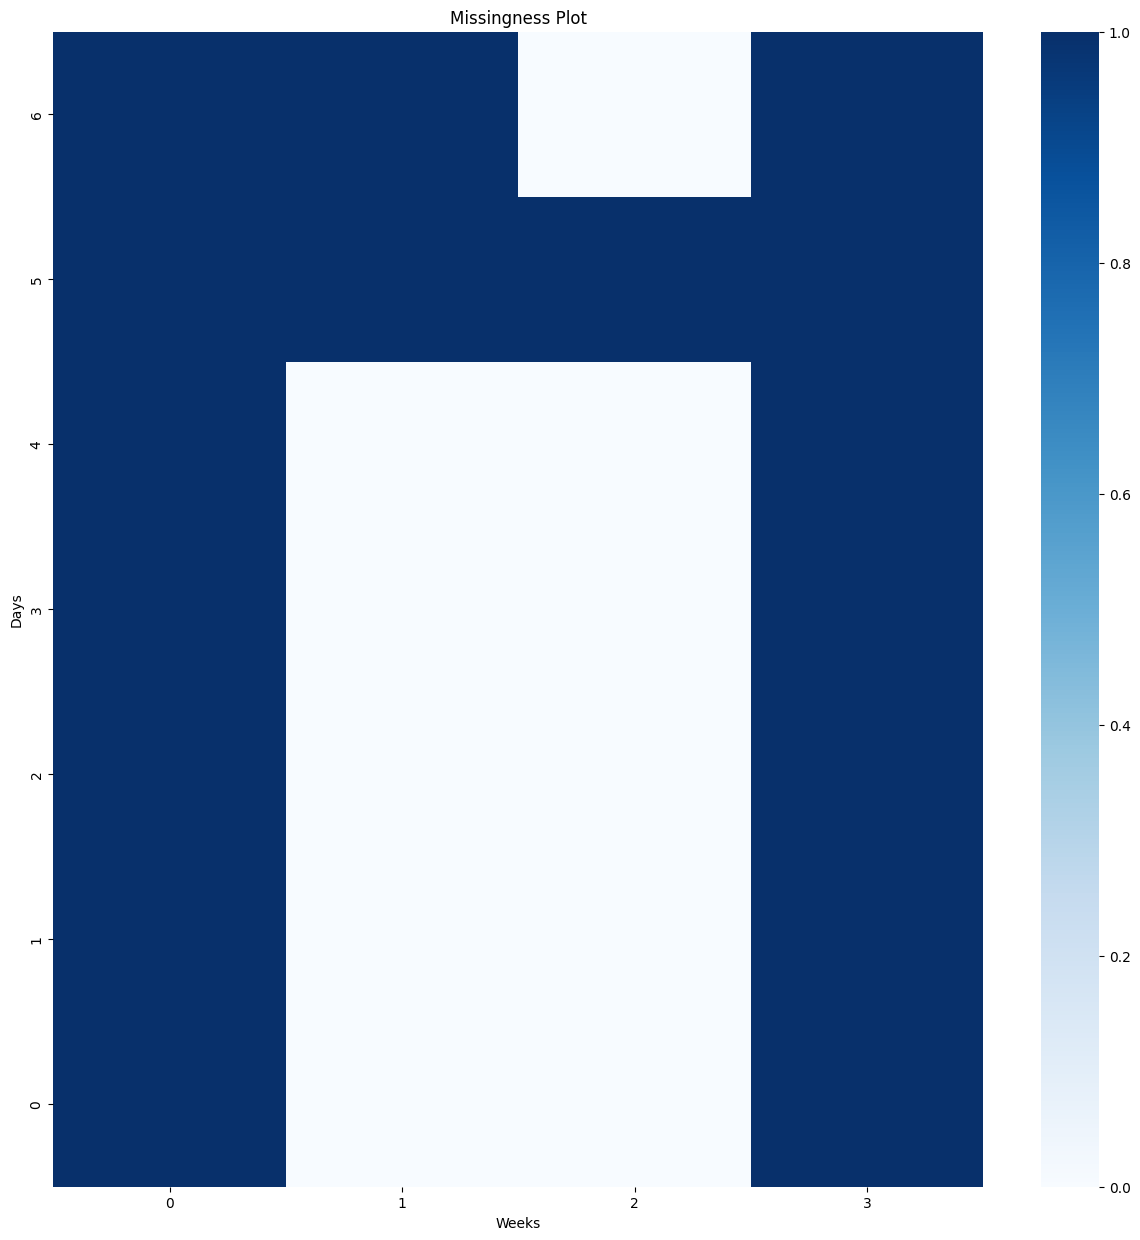

In [18]:
plot_data = MissingPatternPlot.initialize(missingness_avg, None, 'study_period', None)
plot_data.plot('person_id', direction=False, y_label='Days', y_ticks=True, x_ticks='auto', x_label='Weeks', color_bar=True, cmap='Blues')